# Tarea 2 — Reconstrucción 3D con COLMAP
**IIC3912 Tópicos Avanzados de Gráfica Computacional**

Este notebook es el punto de partida común para todos los experimentos.
Ejecuta las celdas en orden para instalar dependencias, montar Drive y descargar el dataset.

In [1]:
# Instalación de dependencias
!pip install pycolmap plotly open3d pandas tqdm -q

import os, shutil, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pycolmap
from pathlib import Path
from PIL import Image as PILImage

print('pycolmap:', pycolmap.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.1/27.1 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 58.3 MB/s eta 0:00:00
pycolmap: 4.0.4


In [2]:
SCENES = ['garden', 'bicycle', 'bonsai', 'counter']

IMG_SCALE = 4  # resolución: 1 (full), 2, 4, 8  — se recomienda 4 en Colab CPU

In [3]:
# ── Google Drive y paths ───────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE = Path('/content/drive/MyDrive/tarea2_mipnerf')
BASE       = Path('/content/colmap_work')
DRIVE_BASE.mkdir(parents=True, exist_ok=True)

def scene_paths(scene):
    return {
        'drive'   : DRIVE_BASE / scene,
        'images'  : BASE / scene / 'images',
        'sparse'  : BASE / scene / 'sparse',
        'db'      : BASE / scene / 'colmap.db',
    }

# Crear directorios de trabajo para todas las escenas
for scene in SCENES:
    p = scene_paths(scene)
    for d in [p['images'], p['sparse'] / 'student', p['sparse'] / 'official']:
        d.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# ── Descarga y extracción del dataset ─────────────────────────────────────
# El zip (~1.8 GB) se descarga una sola vez a Drive.
# Las sesiones siguientes lo reutilizan directamente.

DATASET_URL = 'https://storage.googleapis.com/gresearch/refraw360/360_v2.zip'
ZIP_PATH    = DRIVE_BASE / '360_v2.zip'

def download_and_extract(scene):
    dst = DRIVE_BASE / scene
    if dst.exists():
        print(f'[{scene}] ya en Drive')
        return
    if not ZIP_PATH.exists():
        print('Descargando dataset (~1.8 GB)...')
        ret = os.system(f'wget -q --show-progress -O "{ZIP_PATH}" "{DATASET_URL}"')
        if ret != 0:
            raise RuntimeError('Descarga fallida. Sube el zip manualmente a Drive.')
    print(f'[{scene}] extrayendo...')
    ret = os.system(f'unzip -q "{ZIP_PATH}" "{scene}/*" -d "{DRIVE_BASE}"')
    if ret != 0 or not dst.exists():
        raise RuntimeError(f'Error extrayendo {scene}')
    print(f'[{scene}] listo en {dst}')

def prepare_images(scene):
    paths = scene_paths(scene)
    dst   = paths['images']
    existing = list(dst.glob('*.jpg')) + list(dst.glob('*.JPG')) + list(dst.glob('*.png'))
    if existing:
        print(f'[{scene}] {len(existing)} imágenes ya en local')
        return
    scale_folder = f'images_{IMG_SCALE}' if IMG_SCALE > 1 else 'images'
    src = paths['drive'] / scale_folder
    if not src.exists():
        src = paths['drive'] / 'images'
        print(f'[{scene}] {scale_folder}/ no encontrada → usando images/')
    imgs = sorted(list(src.glob('*.jpg')) + list(src.glob('*.JPG')) + list(src.glob('*.png')))
    print(f'[{scene}] copiando {len(imgs)} imágenes desde {src.name}...')
    for img_path in imgs:
        shutil.copy(str(img_path), str(dst / img_path.name))
    with PILImage.open(list(dst.glob('*'))[0]) as im:
        print(f'[{scene}] resolución: {im.size} | total: {len(imgs)} imgs')

# Descargar y preparar las 4 escenas
for scene in SCENES:
    download_and_extract(scene)
    prepare_images(scene)

[garden] ya en Drive
[garden] copiando 185 imágenes desde images_4...
[garden] resolución: (1297, 840) | total: 185 imgs
[bicycle] ya en Drive
[bicycle] copiando 194 imágenes desde images_4...
[bicycle] resolución: (1237, 822) | total: 194 imgs
[bonsai] ya en Drive
[bonsai] copiando 292 imágenes desde images_4...
[bonsai] resolución: (780, 520) | total: 292 imgs
[counter] ya en Drive
[counter] copiando 240 imágenes desde images_4...
[counter] resolución: (779, 519) | total: 240 imgs


a)

Primero que todo, los autores mencionan que cada escena contiene un objeto central o área compleja, con un fondo detallado. Que en cada escena se intentó prevenir variaciones fotometricas, arreglando la configuración de composición de la camara, minimizando variaciones de luz y evitando objetivos que se mueven.

1) counter:
- Tipo: Indoor.
- Descripción visual: Consiste en un mostrador/isla de cocina, donde hay diferentes objetos complejos encima de este, tales como huevos, guantes de horno, naranjas, etc. En el fondo se ven partes de lo que componen una cocina. El ángulo de captura varia desde un frente recto y se mueve hacía arriba, también la distancia varía, principalmente más cercano. Como es escena indor, tiene una fuente de luz difusa.
- Dificultades SfM: Considerando que los autores mencionan las escenas unbounded, las cuales son las que el contenido en la escena aunque se tomen de diferentes distancias no se logra dimensionar el tamaño del contenido, debido a la variedad de objetos que vemos en la imagen, y que existe una idea general de que tamaño tienen las cosas de la cocina, no debería generar muchos problemas. Por otro lado, los autores mencionan que siempre es un problema a considerar las estructuras que son muy delgadas y con muchos detalles, considerando que hay hartos detalles a considerar, y objetos bastante cercanos entre sí, por lo que tendrá este tipo de problemas la escena.

2) garden
- Tipo: Outdoor.
- Descripción visual: Consiste en una mesa circular en el centro de la imagen, con un florero con objetos complejos tipo flores/ramas de madera. Con el fondo un jardín, donde se ven plantas y parte de una casa/edificio. Los ángulos desde los que se toman las imagenes varia poco desde arriba o más abajo, pero si varía la cercanía desde donde se captura. Los autores mencionan que para escenas outdoor, capturaron las imagenes cuando el cielo estaba nublado para obtener sombras suaves.
- Dificultades: Considerando que los autores mencionan las escenas unbounded, las cuales son las que el contenido en la escena aunque se tomen de diferentes distancias no se logra dimensionar el tamaño del contenido, debido a que los detalles del fondo, tales como arboles, arbustos, la casa, no debería generar este problema con el "florero" al menos. Por otro lado, los autores mencionan que siempre es un problema a considerar las estructuras que son muy delgadas y con muchos detalles, considerando que en el fondo hay hartos detalles, sobre todo las arbustos, sus hojas/ramas, luego en el objeto central hay figuras bastante delgadas que probablemente generarán problemas.

3) bicycle:
- Tipo: Outdoor.
- Descripción visual: Consiste en una bicicleta en el centro de la imagen, apoyada en un banco(tipo plaza/parque). Con el fondo una plaza o parque, donde se ve harta vegetación y arboles, y el cielo, en algunas escenas de forma predominante como fondo. Los ángulos desde donde se toman las capturas varía bastante, pero enfocandose más arriba de la bicicleta, a veces apareciendo solo el manubrio, o veces nada de la bicicleta. En esta escena se hace más evidente que imagenes se tomaron con el cielo nublado.
- Dificultades SfM: Respecto a las escenas unbounded, dado que el fondo tiene varios detalles, está bien "ambientado", hay objetos respecto a los que se puede comparar el tamaño y dar una idea al respecto. Por otro lado, como los mismos autores mencionan, muy probablemente los rayos de la bicicleta generaría problemas.

4) bonsai
- Tipo: Indoor.
- Descripción visual: Es un bonsai pequeño en el medio de la imagen, sobre una mini mesa donde cae solamente el bonsai. El fondo se ve el interior de una pieza, con diferentes cosas/objetos. Los ángulos de captura varia bastante para capturar desde arriba y desde abajo el bonsai. En el caso de escenas indoor, los autores mencionan que buscaron que en las escena hubiera grandes fuentes de luz difusa.
- Dificultades SfM: Respecto a escenas unbounded, debido a que de igual forma que en las otras escenas, hay hartos detalles, y más cercanos al ser indoor, permite definir dimensiones del objeto. Por otro lado, hablando solo del objeto central, es muy posible que las piedritas dentro del macetero del bonsai generen problemas, además de que las flores son tan pequeñas que incluso en algunas imagenes se ven un poco difusas, lo cual claramente será un problema.




b) En la parte de descarga y extracción del dataset se entregaron los datos de número de imágenes y de resolución, que detallamos aquí:
- garden: N° imagenes: 185, Resolución:1297x840 pixeles
- bicycle: N° imagenes: 194, Resolución:1237x822 pixeles
- bonsai: N° imagenes: 292, Resolución:780x520 pixeles
- counter: N° imagenes: 240, Resolución:779x519 pixeles

Mientras que la variación de las condiciones de captura se comentaron en el inciso a), en la parte de características visuales.

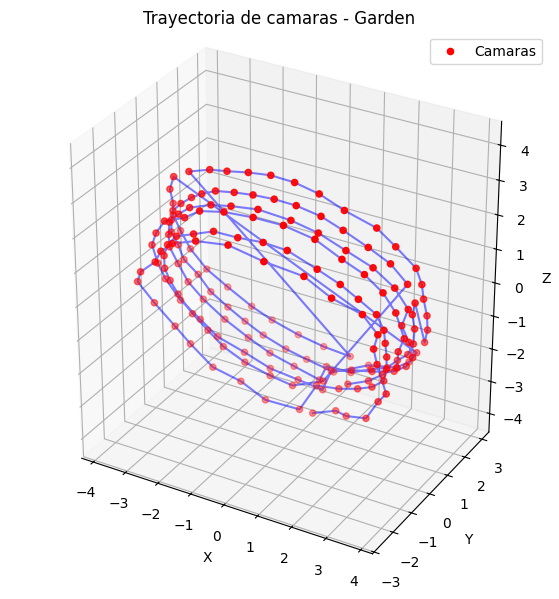

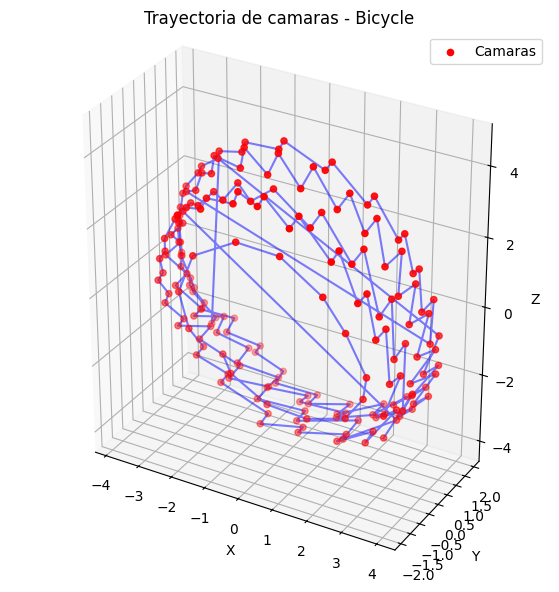

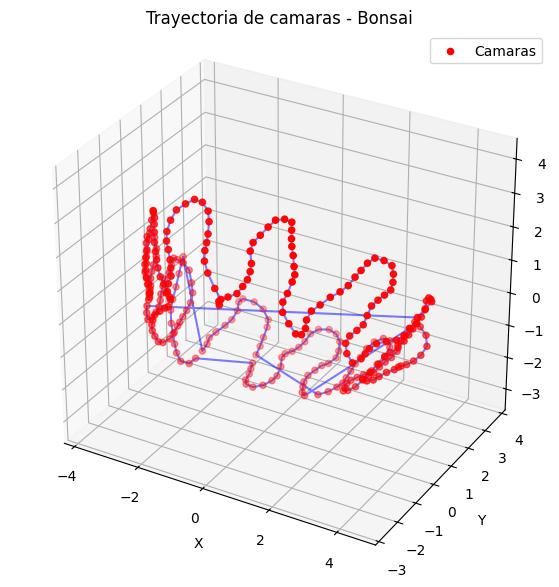

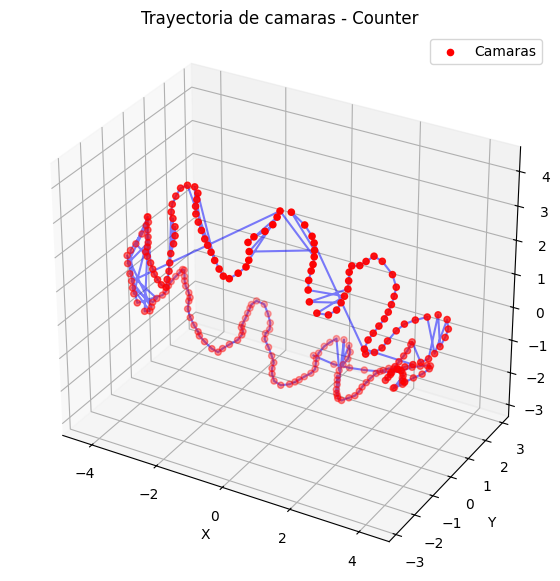

In [11]:
# c)

for scene in SCENES:
    paths = scene_paths(scene)
    official_dir = paths['drive'] / 'sparse' / '0'
    reconstruction = pycolmap.Reconstruction(official_dir)

    pos_camara = np.array([img.projection_center() for img in reconstruction.images.values()])

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(pos_camara[:, 0], pos_camara[:, 1], pos_camara[:, 2],
               color='red', s=20, label='Camaras')

    ax.plot(pos_camara[:, 0], pos_camara[:, 1], pos_camara[:, 2],
               color='blue', linestyle='-', alpha=0.5)

    ax.set_title(f'Trayectoria de camaras - { scene.capitalize()}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    ax.set_box_aspect([np.ptp(pos_camara[:, 0]), np.ptp(pos_camara[:, 1]), np.ptp(pos_camara[:, 2])])
    plt.legend()

    fig.show()

In [ ]:
# d) Estadísticas
print("\n - Estadísticas ")
for scene in SCENES:
    paths = scene_paths(scene)
    official_dir = paths['drive'] / 'sparse' / '0'

    rec = pycolmap.Reconstruction(official_dir)

    orig_n_cams = len(rec.images)
    orig_n_pts = len(rec.points3D)

    error_prom = rec.compute_mean_reprojection_error()

    print(f'{scene}')
    print(f'- Camaras registradas: {orig_n_cams}')
    print(f'- Puntos 3D           : {orig_n_pts}')
    print(f'- Error de reproyeccion: {error_prom:.4f} px\n´')
#


--- Estadísticas Oficiales ---
garden
- Camaras registradas: 185
- Puntos 3D           : 138766
- Error de reproyeccion: 1.1966 px
´
bicycle
- Camaras registradas: 194
- Puntos 3D           : 54275
- Error de reproyeccion: 1.2004 px
´
bonsai
- Camaras registradas: 292
- Puntos 3D           : 206613
- Error de reproyeccion: 0.7739 px
´
counter
- Camaras registradas: 240
- Puntos 3D           : 155767
- Error de reproyeccion: 0.7400 px
´
